In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
import datasets

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs("artifacts", exist_ok=True)

Device: cuda


In [ ]:
ds = datasets.load_dataset("emotion")
print("Split sizes:")
print(f"  Train:        {len(ds['train'])}")
print(f"  Validation:   {len(ds['validation'])}")
print(f"  Test:         {len(ds['test'])}")

label_names = ds["train"].features["label"].names
label2id = {lbl: i for i, lbl in enumerate(label_names)}
id2label = {i: lbl for lbl, i in label2id.items()}
print(f"\nClasses ({len(label_names)}): {label_names}")

print("\n3 random examples from train:")
for i in range(3):
    idx = random.randint(0, len(ds["train"])-1)
    text = ds["train"][idx]["text"]
    lbl = id2label[ds["train"][idx]["label"]]
    print(f"[{lbl}] {text[:90]}...")

Split sizes:
  Train:        16000
  Validation:   2000
  Test:         2000

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

3 random examples from train:
[sadness] i do find new friends i m going to try extra hard to make them stay and if i decide that i...
[joy] i asked them to join me in creating a world where all year old girls could grow up feeling...
[love] i feel when you are a caring person you attract other caring people into your life...


In [ ]:
MODEL_FINETUNE = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_FINETUNE)

sample_texts = [
    "I am so happy and excited about this!",
    "Why does this keep happening? I'm furious.",
    "Just saw a dog. It was okay."
]

print(f"Model max_length: {tokenizer.model_max_length}\n")
for text in sample_texts:
    enc = tokenizer(text, truncation=True, max_length=16, padding="max_length", return_attention_mask=True)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    special = [t for t in tokens if t in tokenizer.all_special_tokens]
    
    print(f"Text: {text}")
    print(f"Tokens ({len(tokens)}): {tokens}")
    print(f"Input IDs: {enc['input_ids']}")
    print(f"Attention Mask: {enc['attention_mask']}")
    print(f"Special tokens present: {special}")
    print("-" * 50)

Model max_length: 512

Text: I am so happy and excited about this!
Tokens (16): ['[CLS]', 'i', 'am', 'so', 'happy', 'and', 'excited', 'about', 'this', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 1045, 2572, 2061, 3407, 1998, 7568, 2055, 2023, 999, 102, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
Special tokens present: ['[CLS]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
--------------------------------------------------
Text: Why does this keep happening? I'm furious.
Tokens (16): ['[CLS]', 'why', 'does', 'this', 'keep', 'happening', '?', 'i', "'", 'm', 'furious', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 2339, 2515, 2023, 2562, 6230, 1029, 1045, 1005, 1049, 9943, 1012, 102, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
Special tokens present: ['[CLS]', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
--------------------------------------------------
Text: Just saw a dog. It 

In [ ]:


MODEL_INFERENCE = "j-hartmann/emotion-english-distilroberta-base"

inf_tokenizer = AutoTokenizer.from_pretrained(MODEL_INFERENCE)
inf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_INFERENCE,
    use_safetensors=True 
)
inf_model.eval()

demo_texts = [
    "Got the promotion! Feeling amazing today!",
    "Everything is falling apart, I can't cope.",
    "The system response time is 230ms. Acceptable.",
    "Not sure what to expect, but I hope for the best.",
    "My cat just knocked over my coffee. I'm livid."
]

results = []
for txt in demo_texts:
    inputs = inf_tokenizer(txt, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = inf_model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    pred_idx = probs.argmax(dim=-1).item()
    pred_label = inf_model.config.id2label[pred_idx]
    conf = probs[0, pred_idx].item()
    results.append({"text": txt, "pred_label": pred_label, "confidence": round(conf, 3)})

df_inf = pd.DataFrame(results)
display(df_inf)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,pred_label,confidence
0,Got the promotion! Feeling amazing today!,surprise,0.634
1,"Everything is falling apart, I can't cope.",sadness,0.939
2,The system response time is 230ms. Acceptable.,neutral,0.950
3,"Not sure what to expect, but I hope for the best.",neutral,0.860
4,My cat just knocked over my coffee. I'm livid.,anger,0.931


In [30]:
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_ds = ds.map(tokenize_function, batched=True, remove_columns=["text"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Dataset tokenized. Keys:", list(tokenized_ds["train"].features.keys()))

Dataset tokenized. Keys: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./outputs_hw13",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none"
)

In [32]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_FINETUNE,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)
model.to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
train_result = trainer.train()
print("Fine-tuning completed.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.241972,0.197548,0.929000,0.903832
2,0.151942,0.160914,0.936000,0.911313
3,0.093872,0.146540,0.941000,0.916758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Fine-tuning completed.


Test Accuracy: 0.9245
Test F1 (macro): 0.8756


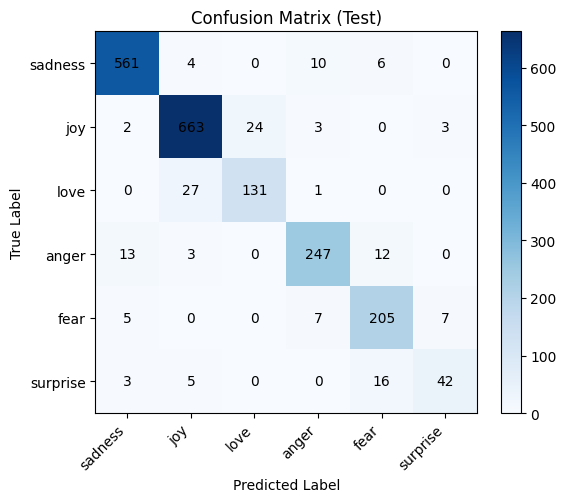

In [ ]:
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)

test_metrics = trainer.evaluate(tokenized_ds["test"])
print(f"Test Accuracy: {test_metrics['eval_accuracy']:.4f}")
print(f"Test F1 (macro): {test_metrics['eval_f1_macro']:.4f}")

test_output = trainer.predict(tokenized_ds["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true = test_output.label_ids

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
plt.colorbar()
ticks = np.arange(len(label_names))
plt.xticks(ticks, label_names, rotation=45, ha="right")
plt.yticks(ticks, label_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
for i in range(len(label_names)):
    for j in range(len(label_names)):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="black")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

In [ ]:
test_texts = ds["test"]["text"]
probs = torch.nn.functional.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
confidences = np.max(probs, axis=1)

pred_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[l] for l in test_true],
    "pred_label": [id2label[l] for l in test_preds],
    "confidence": np.round(confidences, 3)
})

errors_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]].sort_values("confidence", ascending=False)
sample_df = pd.concat([pred_df.head(5), errors_df.head(5)]).drop_duplicates().reset_index(drop=True)
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)

display(sample_df.head(10))

print("\n Анализ ошибок:")
if len(errors_df) > 0:
    for _, row in errors_df.head(3).iterrows():
        print(f"Text: {row['text'][:95]}...")
        print(f"True: {row['true_label']} | Pred: {row['pred_label']} | Conf: {row['confidence']:.3f}")
        print("-" * 60)
else:
    print("Ошибок нет")

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.999
1,im updating my blog because i feel shitty,sadness,sadness,0.999
2,i never make her separate from me because i do...,sadness,sadness,0.999
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.999
4,i was feeling a little vain when i did this one,sadness,sadness,0.999
5,whenever i put myself in others shoes and try ...,anger,joy,0.999
6,i feel inside cause life is like a game someti...,fear,sadness,0.998
7,i actually was in a meeting last week where so...,anger,sadness,0.997
8,i walked to school he felt the bounce in his s...,love,joy,0.997
9,i just feel are ludicrous and wasting space or...,surprise,sadness,0.996



 Анализ ошибок:
Text: whenever i put myself in others shoes and try to make the person happy...
True: anger | Pred: joy | Conf: 0.999
------------------------------------------------------------
Text: i feel inside cause life is like a game sometimes but then you came around me the walls just di...
True: fear | Pred: sadness | Conf: 0.998
------------------------------------------------------------
Text: i actually was in a meeting last week where someone yelled at an older lady because her phone r...
True: anger | Pred: sadness | Conf: 0.997
------------------------------------------------------------
